In [1]:
# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model

# 0. Preprocess + EDA + Feature Selection

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv('/workspaces/Machine-Learning-with-Python/ML/placement.csv')
df

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0
...,...,...,...,...
95,95,4.3,200.0,0
96,96,4.4,42.0,0
97,97,6.7,182.0,1
98,98,6.3,103.0,1


In [3]:
df.shape

(100, 4)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [5]:
df = df.iloc[:, 1:]
df

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


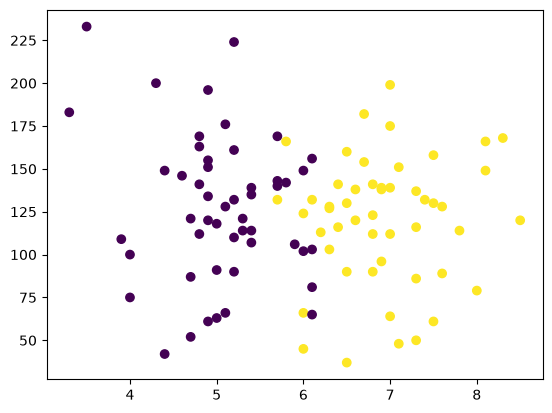

In [6]:
plt.scatter(df['cgpa'], df['iq'], c=df['placement'])
plt.show()

# 1. Extract input and output cols

In [7]:
x = df.iloc[:, 0:2]
y = df.iloc[:, 2:] # [:, -1]


# 3. Train test split

In [8]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test= train_test_split(x, y, test_size=0.1)

y_train

,placement
24,0
9,0
59,0
31,0
27,1
...,...
86,0
69,1
3,1
26,1


In [9]:
from sklearn.preprocessing import StandardScaler

scaler  = StandardScaler()

In [10]:
x_train = scaler.fit_transform(x_train)
x_train

array([[-1.21103519, -0.09050789],
       [-0.85368054, -1.48185586],
       [-1.12169653, -0.31818301],
       [-1.92574448, -0.39407472],
       [-0.04963259, -0.01461618],
       [ 0.48639938, -0.11580512],
       [ 0.39706072, -2.2154757 ],
       [ 0.03970607, -1.10239732],
       [ 0.75441536,  0.36484236],
       [ 0.21838339, -0.54585813],
       [-0.58566456, -0.26758854],
       [ 0.84375403, -1.53245033],
       [ 0.21838339,  0.06127553],
       [-1.03235787,  0.23835618],
       [-0.13897125, -0.46996643],
       [ 0.39706072,  0.89608431],
       [ 0.93309269, -1.93720611],
       [ 1.11177001, -0.21699407],
       [ 1.379786  , -0.90001944],
       [ 0.84375403,  1.27554285],
       [ 0.30772206,  0.41543683],
       [ 0.57573804,  0.7443009 ],
       [-1.30037385,  0.54192301],
       [ 0.03970607, -0.54585813],
       [-0.04963259,  0.61781472],
       [-1.03235787,  0.76959813],
       [ 0.84375403,  0.36484236],
       [-0.22830991,  1.04786773],
       [ 0.6650767 ,

In [11]:
x_test = scaler.transform(x_test)

x_test

array([[-0.58566456, -0.44466919],
       [-0.31764857,  0.18776171],
       [-1.21103519, -0.95061391],
       [ 0.57573804,  1.4526235 ],
       [-0.76434188,  0.92138155],
       [-1.83640582, -1.25418074],
       [-1.47905117, -2.08898952],
       [-0.94301921, -0.84942497],
       [ 1.8264793 ,  0.61781472],
       [-1.03235787, -0.11580512]])

In [12]:
from sklearn.linear_model import LogisticRegression as LR

clf = LR()



In [13]:
clf.fit(x_train, y_train)

/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [14]:
y_pred= clf.predict(x_test)
y_pred

array([0, 0, 0, 1, 0, 0, 0, 0, 1, 0])

In [15]:
y_test

,placement
81,0
87,1
23,0
97,1
47,0
68,0
96,0
25,0
37,1
22,0


In [16]:
df.iloc[63,:]

cgpa           6.3
iq           128.0
placement      1.0
Name: 63, dtype: float64

In [17]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.9

<Axes: >

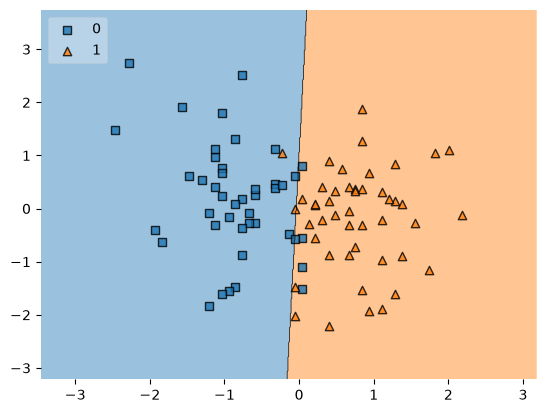

In [23]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(x_train, y_train.values.ravel(), clf=clf, legend=2)